<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
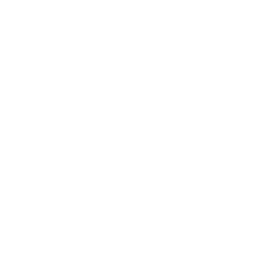
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bewaking van het walsproces in de staalfabriek</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariate SPC voor dikte- en oppervlaktekwaliteitsbewaking in een warmbandwalserij &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Samenvatting

Een warmbandwalserij walst staalplakken tot dunne coils. Acht onderling
gecorreleerde procesignalen (dikten, walskracht, walsspleet, motorstroom,
uitgangstemperatuur) bewegen samen wanneer de lijn gezond is, dus ze één
voor één bewaken mist juist de gezamenlijke verschuivingen die ertoe doen.
Dit voorbeeld bouwt een multivariate baseline met **PROC MVPMODEL** en
stuurt vervolgens 100 productiecoils door **PROC MVPMONITOR**, dat elke
coil scoort met één Hotelling's *T*&sup2;-statistiek en die vergelijkt met
een controlegrens.

Tegen een controlegrens van *T*&sup2; = **17,13** (&alpha; = 0,05),
signaleren **4 van de 100 coils** een toestand buiten controle — coils
**91, 92, 94 en 95**, precies het venster waarin een trillingsuitbarsting
van de steunwals is geïnjecteerd. De piekwaarde *T*&sup2; bereikt **21,91**
bij coil 95, ongeveer **1,3&times;** de controlegrens. De geleidelijke
walsslijtage over de latere coils tilt de baseline-*T*&sup2; op, maar
blijft onder de grens tot het trillingsincident, zodat de kaart een
duidelijk onderscheid maakt tussen langzame drift en het acute defect dat
onmiddellijke aandacht vereist.

## Gegevensbronnen

- **mill_baseline** &mdash; 50 coils gewalst tijdens een bekend goede
  periode van de campagne; gebruikt om het multivariate (PCA)
  referentiemodel te fitten.
- **mill_stream** &mdash; 100 coils van de productielijn. Coils
  1&ndash;55 verlopen onder controle; walsslijtage ontwikkelt zich
  geleidelijk over coils 56&ndash;100; een trillingsuitbarsting van de
  steunwals treft coils 91&ndash;95.
- **Procesvariabelen** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> De omgeving draait ongelicentieerd, dus datasets zijn beperkt tot 100
> observaties. Het scenario is daarop afgestemd: de verstoring wordt laat
> in een reeks van 100 coils geplaatst in plaats van bij coil 2.800 van
> 5.000.

---

### Stap 1 &mdash; Bouw het multivariate referentiemodel

`PROC MVPMODEL` voert een hoofdcomponentenanalyse uit van de zes
procesvariabelen op de baseline onder controle en schrijft de ladingen,
eigenwaarden en centrering/schaling naar `mill_model`. Drie componenten
worden behouden. Dit model definieert wat "normaal" is als één
multivariate regio in plaats van zes onafhankelijke bereiken.

In [1]:
GEGEVENS mill_baseline;
  CALL streaminit(66);
  DOE coil_id = 1 TOT 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    UITVOER;
  EINDE;
UITVOEREN;

PROCEDURE mvpmodel GEGEVENS=mill_baseline outmodel=mill_model;
  VARIABELE entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  LABEL entry_thickness='Ingangsdikte'
        exit_thickness='Uitgangsdikte'
        rolling_force='Walskracht'
        roll_gap='Walsspleet'
        motor_current='Motorstroom'
        exit_temp='Uittemperatuur';
  ncomp=3;
UITVOEREN;



                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         IngangsdikteUitgangsdikteWalskrachtWalsspleetMotorstroomUittemperatuur
  Ingangsdikte    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  Uitgangsdikte   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  Walskracht   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  Walsspleet   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  Motorstroom    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  Uittemperatuur    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3 1.0621


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Stap 2 &mdash; Stream de productiecoils en scoor ze

`PROC MVPMONITOR` projecteert elk van de 100 productiecoils op het
opgeslagen model en berekent de Hotelling's *T*&sup2;. De procedure
leidt de controlegrens af uit de modeldimensies en de standaard
&alpha; = 0,05, en markeert vervolgens elke coil waarvan *T*&sup2; die
grens overschrijdt. De resultaten, inclusief de kolommen `_TSQUARED`,
`_LIMIT` en `_SIGNAL`, worden weggeschreven naar `mill_scores`, gesleuteld
op `coil_id`.

In [2]:
GEGEVENS mill_stream;
  CALL streaminit(42);
  DOE coil_id = 1 TOT 100;
    /* walsslijtage loopt op van 0 naar 1 over coils 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* trillingsuitbarsting van de steunwals bij coils 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    VERWIJDEREN wear chatter;
    UITVOER;
  EINDE;
UITVOEREN;

PROCEDURE mvpmonitor GEGEVENS=mill_stream MODEL=mill_model
                out=mill_scores;
  VARIABELE entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  LABEL entry_thickness='Ingangsdikte'
        exit_thickness='Uitgangsdikte'
        rolling_force='Walskracht'
        roll_gap='Walsspleet'
        motor_current='Motorstroom'
        exit_temp='Uittemperatuur'
        coil_id='Coil-ID';
  id coil_id;
UITVOEREN;



                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4
  Variables Monitored: Ingangsdikte, Uitgangsdikte, Walskracht, Walsspleet, Motorstroom, Uittemperatuur





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


De proceduresamenvatting rapporteert de controlegrens en het aantal
signalen. Hieronder toont de afgedrukte doorsnede rond de verstoring dat
de baseline-coils ruim onder de grens blijven terwijl het trillingsvenster
vier coils erboven duwt.

In [3]:
/* Markeer coils buiten controle en leg de alarm-T2 vast voor de grafiek */
GEGEVENS mill_scores;
  INSTELLEN mill_scores;
  ALS _SIGNAL = 1 DAN t2_alarm = _TSQUARED;
  ANDERS t2_alarm = .;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=mill_scores(firstobs=88 obs=96) noobs;
  VARIABELE coil_id _TSQUARED _LIMIT _SIGNAL;
  LABEL coil_id='Coil-ID'
        _TSQUARED='T2'
        _LIMIT='Controlegrens'
        _SIGNAL='Signaal';
  TITEL 'T2-scores in het trillingsvenster (coils 88-96)';
UITVOEREN;


                                    T2-scores in het trillingsvenster (coils 88-96)                                     

Coil-ID         T2  Controlegrens  Signaal
     88   9.983151      17.133408        0
     89   2.915646      17.133408        0
     90    7.80613      17.133408        0
     91  18.813814      17.133408        1
     92  18.249361      17.133408        1
     93  16.638221      17.133408        0
     94  17.981792      17.133408        1
     95  21.912329      17.133408        1
     96   5.118574      17.133408        0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Stap 3 &mdash; Multivariate controlekaart

De grafiek legt de *T*&sup2; per coil over de controlegrens heen. Coils
buiten controle zijn rood gemarkeerd; de gestippelde verticale lijn
markeert het begin van de trillingsuitbarsting. De langzame stijging naar
rechts is walsslijtage die de baseline optilt; de vier rode punten zijn
het acute trillingsdefect.

                                    T2-scores in het trillingsvenster (coils 88-96)                                     




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


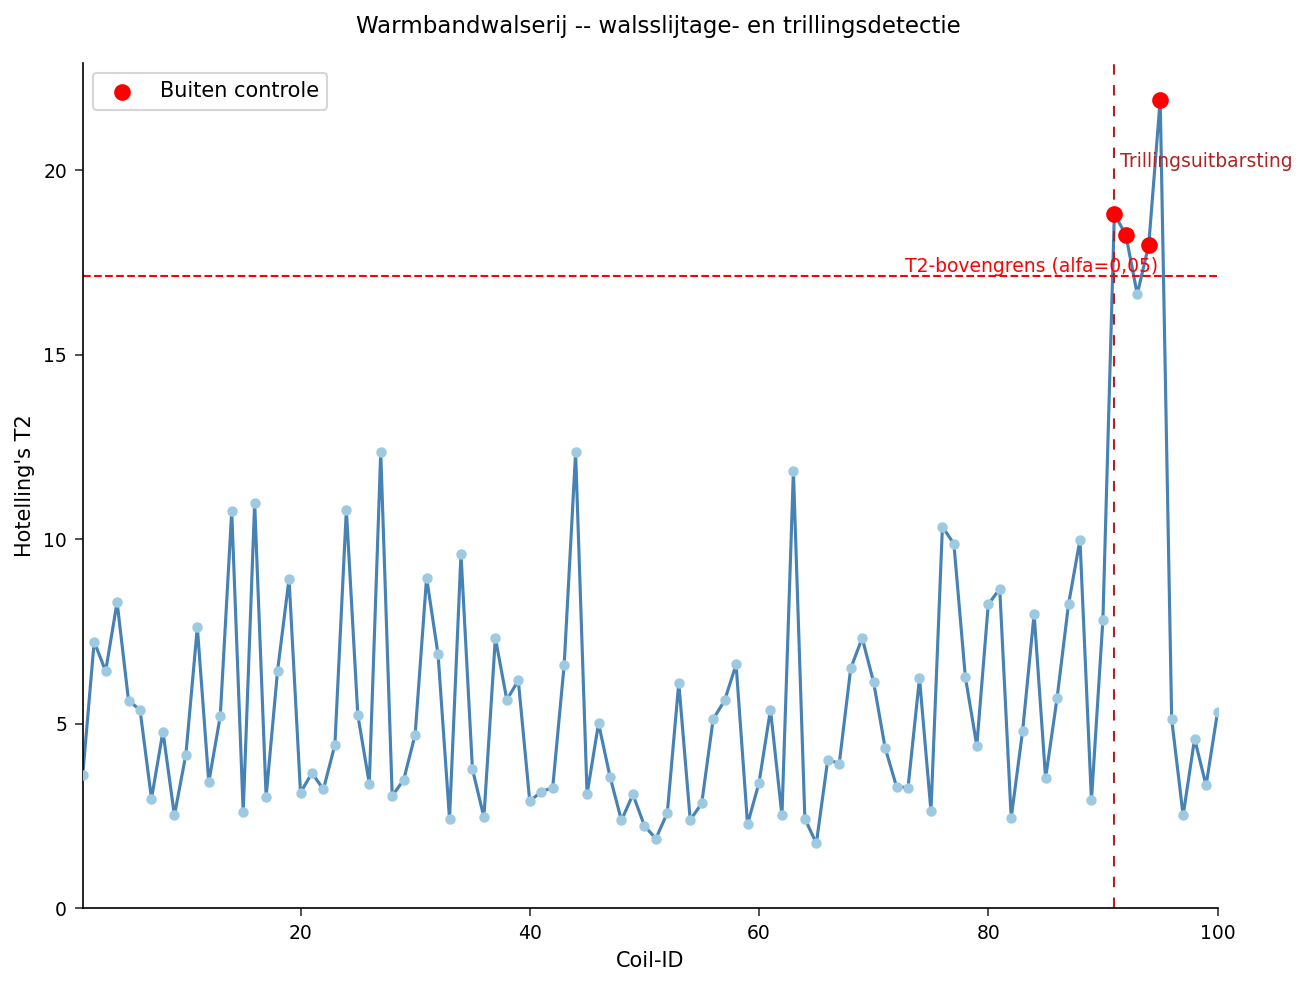

In [4]:
PROCEDURE SGPLOT GEGEVENS=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Buiten controle';
  REFLINE _LIMIT / AXIS=y
          label='T2-bovengrens (alfa=0,05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x label='Trillingsuitbarsting'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS label='Coil-ID' MIN=1 MAX=100;
  YAXIS label="Hotelling's T2" MIN=0;
  TITEL 'Warmbandwalserij -- walsslijtage- en trillingsdetectie';
UITVOEREN;


---

### Stap 4 &mdash; Kwantificeer de coils buiten controle

De coils buiten controle worden naar een aparte dataset voor de
kwaliteitsdesk geleid. `PROC MEANS` zet het *T*&sup2;-niveau van de
gemarkeerde coils af tegen de populatie onder controle, en de gemarkeerde
coils worden geëxporteerd voor verdere afkeur-/herbewerkingsroutering.

In [5]:
GEGEVENS mill_ooc;
  INSTELLEN mill_scores;
  ALS _SIGNAL = 1;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=mill_scores n mean MAX maxdec=2;
  KLASSE _SIGNAL;
  VARIABELE _TSQUARED;
  LABEL _SIGNAL='Signaal' _TSQUARED='T2';
  TITEL 'T2 naar controlestatus (0 = onder controle, 1 = signaal)';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=mill_ooc noobs;
  VARIABELE coil_id _TSQUARED _LIMIT;
  LABEL coil_id='Coil-ID' _TSQUARED='T2' _LIMIT='Controlegrens';
  TITEL 'Coils buiten controle gemarkeerd voor inspectie';
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
UITVOEREN;


                                T2 naar controlestatus (0 = onder controle, 1 = signaal)                                

                                                  The MEANS Procedure

                                            Analysis Variable : _TSQUARED T2

        Signaal           N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                    Coils buiten controle gemarkeerd voor inspectie                                     

Coil-ID         T2  Controlegrens
     91  18.813814      17.133408
     92  18.249361      17.133408
     94  17.981792      17.133408
     95  21.912329      17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Bevindingen

- **Bewaakte coils**: 100; **controlegrens** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Coils buiten controle**: **4** &mdash; coils **91, 92, 94, 95**, alle
  binnen het geïnjecteerde trillingsvenster (91&ndash;95). Coil 93 piekt
  op *T*&sup2; = 16,64, net onder de grens.
- **Piekernst**: *T*&sup2; = **21,91** bij coil 95 (ongeveer 1,3&times;
  de grens); de coils onder controle hebben gemiddeld *T*&sup2; &asymp;
  **5,4**.
- **Slijtage vs. defect**: de geleidelijke walsslijtage tilt de baseline
  van de latere coils op maar overschrijdt de grens nooit op zichzelf,
  zodat de ene multivariate kaart langzame drift (opvolgen) onderscheidt
  van het acute trillingsincident (ingrijpen).
- **Actie**: de vier gemarkeerde coils worden geëxporteerd naar
  `steel_mill_ooc_coils.csv` voor inspectie en afkeur-/
  herbewerkingsroutering; de trillingssignatuur wijst naar het
  steunwallager voor inspectie vóór de volgende campagne.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>